In [2]:
import numpy
import pandas as pd
df01=pd.read_csv("movies.csv")
df02=pd.read_csv("ratings.csv")
df=pd.merge(df01,df02,on="movieId")


Data cleaning + feature engineering

In [3]:
df1=df.drop(["movieId","timestamp","genres"],axis="columns")
df1.head()


,title,userId,rating
0,Toy Story (1995),15,4.0
1,Toy Story (1995),17,5.0
2,Toy Story (1995),23,5.0
3,Toy Story (1995),28,4.0
4,Toy Story (1995),34,3.0


Data visualisation

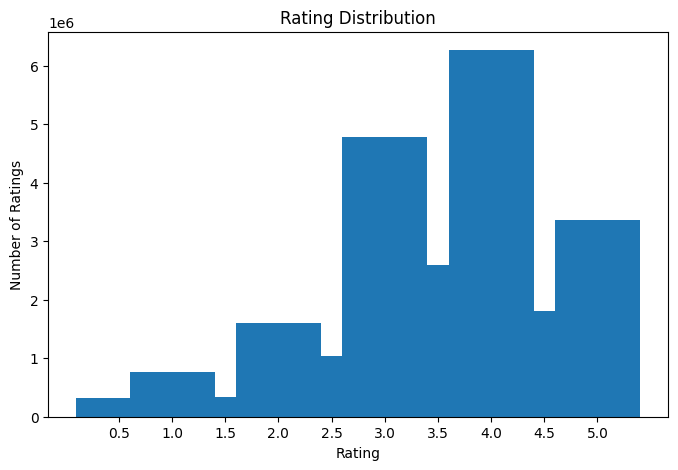

In [4]:
import matplotlib.pyplot as plt

rating_count = df1["rating"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(rating_count.index, rating_count.values)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.xticks(rating_count.index)

plt.show()

In [5]:
grp=df1.groupby("title")["rating"]
ind=grp.size()

movies=ind[ind>=100].index
df2=df1[df1.title.isin(movies)]
print(len(df2.title.unique()),
len(df2.userId.unique()))

9087 247676


In [6]:
grp1=df2.groupby("userId")["title"].size()
users=grp1[grp1>=500].index
df3=df2[df2.userId.isin(users)]
len(df3.title.unique())
len(df3.userId.unique())


7977

creation of user item matrix

In [14]:
user_item_matrix=df3.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)
user_item_matrix.shape


(7977, 9087)

data visulaisation- User-Item Matrix Sparsity

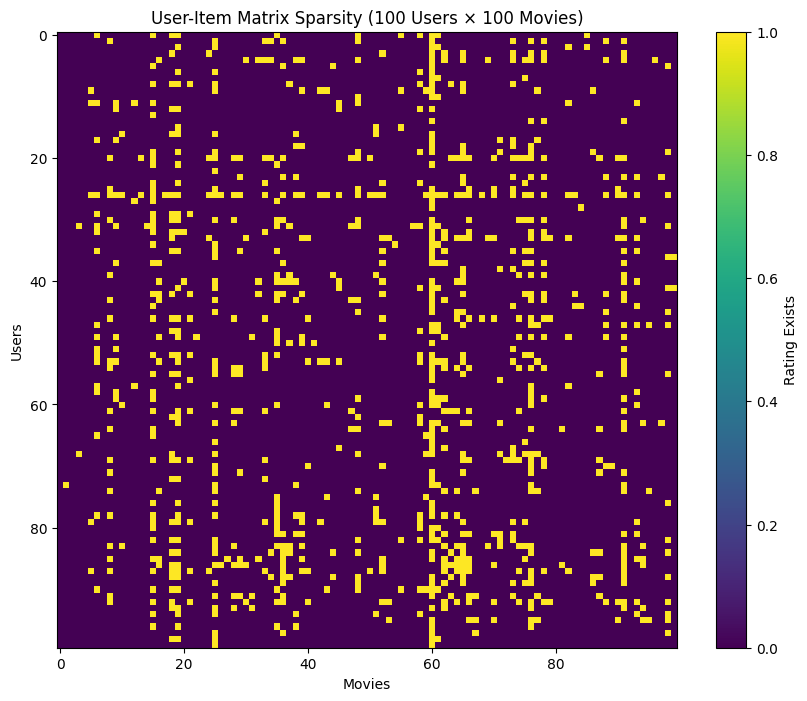

In [15]:
import matplotlib.pyplot as plt

# Display only a small portion of the matrix
sample = user_item_matrix.iloc[:100, :100]

plt.figure(figsize=(10, 8))
plt.imshow(sample.notna(), aspect='auto')

plt.title("User-Item Matrix Sparsity (100 Users × 100 Movies)")
plt.xlabel("Movies")
plt.ylabel("Users")

plt.colorbar(label="Rating Exists")
plt.show()

creation of sparse matirx


In [ ]:
from scipy.sparse import csc_matrix

user_item_matrix=user_item_matrix.fillna(0)


sparse=csc_matrix(user_item_matrix.values)


model fitting


In [10]:
from sklearn.neighbors import NearestNeighbors

knn=NearestNeighbors(
    metric="cosine",
    n_neighbors=10,
    algorithm="brute"
)
knn.fit(sparse)
user_item_matrix.shape

(7977, 9087)

recomendations system workings

In [11]:
distances,index=knn.kneighbors(
    sparse[0],
    n_neighbors=3,
)
movies=user_item_matrix.iloc[0]
movies=movies[movies!=0].index
user1mov=list(movies)
chances=user_item_matrix.iloc[index[0][0]]+user_item_matrix.iloc[index[0][1]]+user_item_matrix.iloc[index[0][2]]
chances[chances<5]=0
chances=chances[chances!=0].index
chancesl=list(chances)
recomendations=[]

for i in chancesl:
    if i not in user1mov and i not in recomendations:
        recomendations.append(i)

print(recomendations[0:5:1])

['12 Angry Men (1957)', 'Absolute Power (1997)', 'Adventures in Babysitting (1987)', 'Affair to Remember, An (1957)', 'Age of Innocence, The (1993)']


In [12]:
import pickle 

with open("knn.pkl","wb") as p:
    pickle.dump(knn,p)
with open("matrix.pkl","wb") as m:
    pickle.dump(user_item_matrix,m)